In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
# Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [9]:
# Load dataset
df = pd.read_csv("Iris.csv")
X = iris.data
y = iris.target

In [11]:
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [13]:
# Convert to DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Dictionary to store results
results = {}

In [19]:
# 1. Linear Regression (not ideal for classification)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = np.round(lr.predict(X_test)).astype(int)
results['Linear Regression'] = accuracy_score(y_test, y_pred_lr)


In [21]:
# 2. Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, y_pred_log)

In [23]:
# 3. Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred_dt)

In [25]:
# 4. Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)

In [27]:
# 5. Neural Network
nn = MLPClassifier(max_iter=500)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
results['Neural Network'] = accuracy_score(y_test, y_pred_nn)

In [29]:
# Print results
print("\nModel Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.2f}")


Model Accuracy Comparison:
Linear Regression: 1.00
Logistic Regression: 1.00
Decision Tree: 1.00
Random Forest: 1.00
Neural Network: 1.00


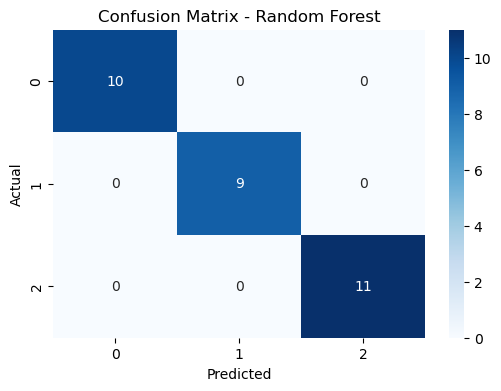

In [31]:
# Confusion Matrix for best model (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()